In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# 1.IMPORTING DATA

In [4]:
file_path =("C:/Users/HP/Downloads/archive (1)/Mall_Customers.csv")
df = pd.read_csv(file_path)

# 2. DATA CLEANING

In [5]:
print("Missing values in each column:\n", df.isnull().sum())

Missing values in each column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


# 3. DATA PREPROCESSING

Encode 'Gender' column

In [6]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# 4. BASIC DATA MANIPULATION

In [7]:
print("\nBasic Statistics:\n", df.describe())
print("\nCorrelation Matrix:\n", df.corr())


Basic Statistics:
        CustomerID      Gender         Age  Annual Income (k$)  \
count  200.000000  200.000000  200.000000          200.000000   
mean   100.500000    0.560000   38.850000           60.560000   
std     57.879185    0.497633   13.969007           26.264721   
min      1.000000    0.000000   18.000000           15.000000   
25%     50.750000    0.000000   28.750000           41.500000   
50%    100.500000    1.000000   36.000000           61.500000   
75%    150.250000    1.000000   49.000000           78.000000   
max    200.000000    1.000000   70.000000          137.000000   

       Spending Score (1-100)  
count              200.000000  
mean                50.200000  
std                 25.823522  
min                  1.000000  
25%                 34.750000  
50%                 50.000000  
75%                 73.000000  
max                 99.000000  

Correlation Matrix:
                         CustomerID    Gender       Age  Annual Income (k$)  \
Custom

# 5. DATA VISUALIZATION

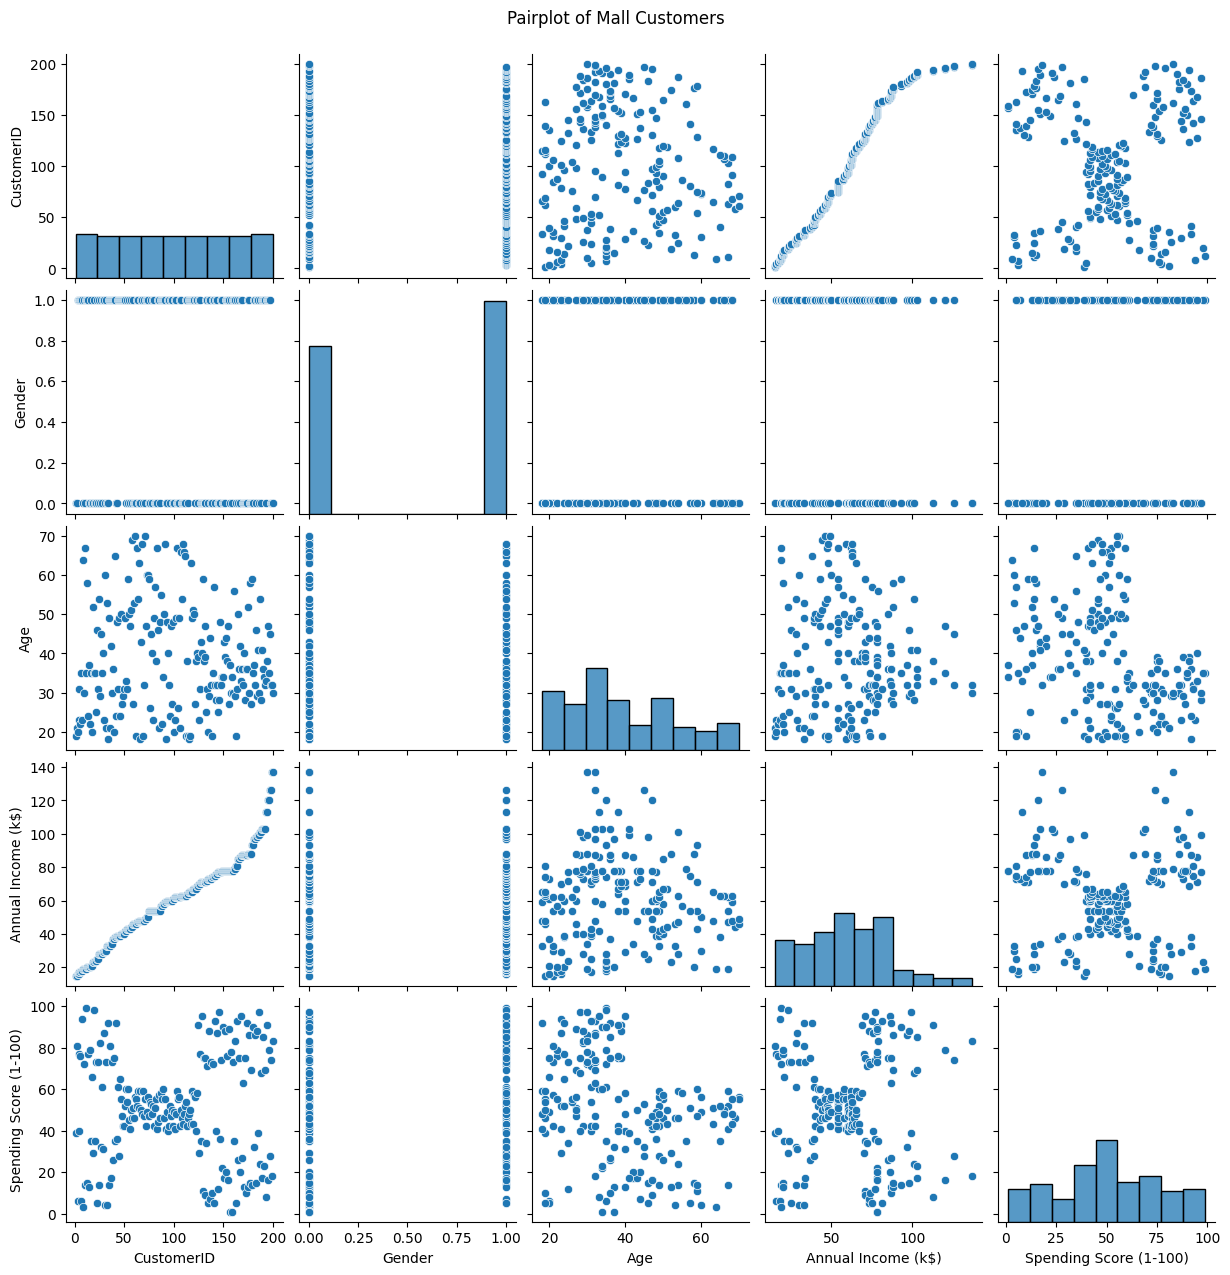

In [8]:
sns.pairplot(df)
plt.suptitle("Pairplot of Mall Customers", y=1.02)
plt.show()

# Histograms Plot

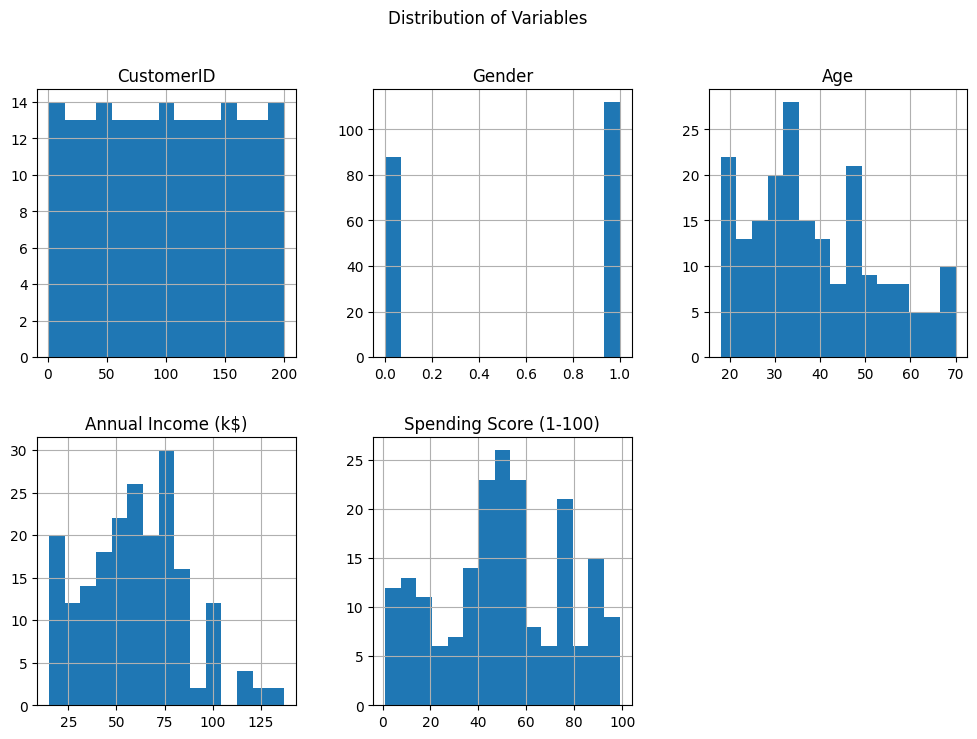

In [9]:
df.hist(bins=15, figsize=(12, 8), layout=(2, 3))
plt.suptitle("Distribution of Variables")
plt.show()

# Boxplots

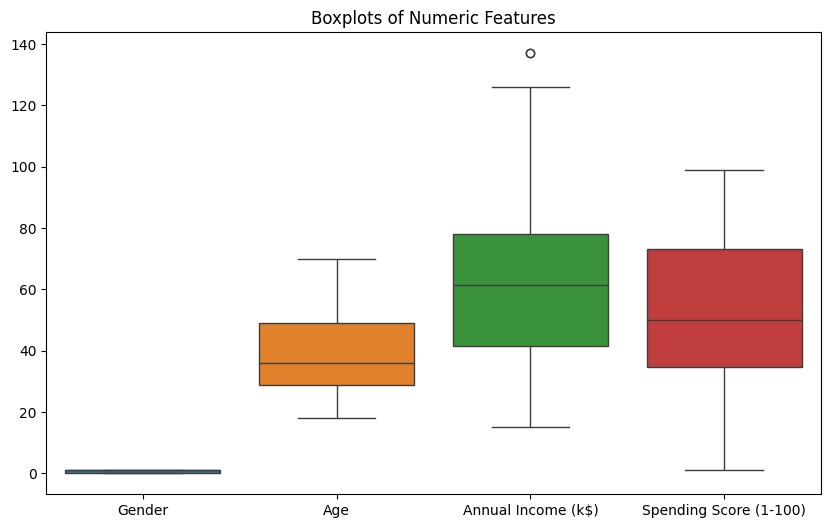

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('CustomerID', axis=1))
plt.title("Boxplots of Numeric Features")
plt.show()

# 6. REGRESSION ANALYSIS

In [11]:
X = df[['Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

# Visual Pictorial Regression

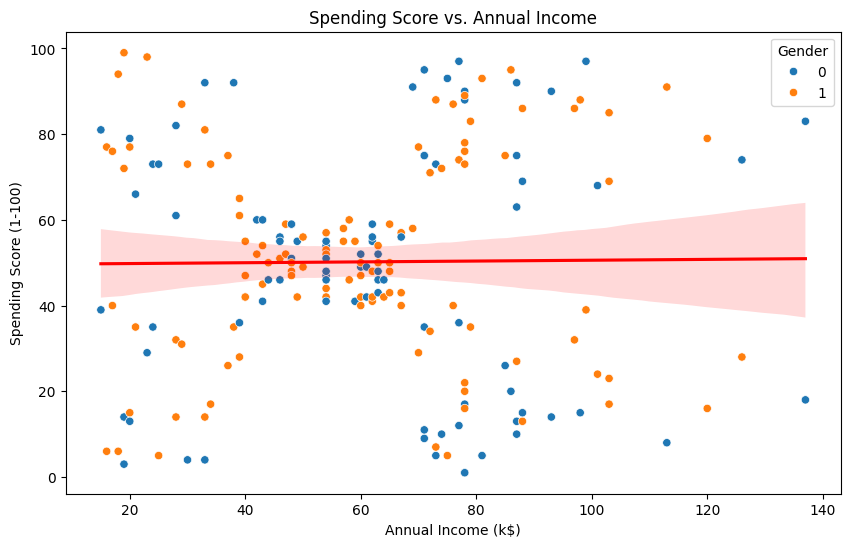

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df)
sns.regplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, scatter=False, color='red')
plt.title("Spending Score vs. Annual Income")
plt.show()

# Linear Regression Model

In [13]:
model = LinearRegression()
model.fit(X, y)
print("\nRegression Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Regression Coefficients: [-0.60478726  0.00574856]
Intercept: 73.34785222186397


# Statsmodels OLS

In [14]:
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print("\nOLS Regression Summary:\n", ols_model.summary())


OLS Regression Summary:
                               OLS Regression Results                              
Dep. Variable:     Spending Score (1-100)   R-squared:                       0.107
Model:                                OLS   Adj. R-squared:                  0.098
Method:                     Least Squares   F-statistic:                     11.82
Date:                    Sat, 03 May 2025   Prob (F-statistic):           1.42e-05
Time:                            13:15:51   Log-Likelihood:                -922.21
No. Observations:                     200   AIC:                             1850.
Df Residuals:                         197   BIC:                             1860.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

# Which One is Spending Lot of Money

C:\Users\HP\AppData\Local\Temp\ipykernel_16548\722576438.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spending_by_age_gender = df.groupby(['AgeGroup', 'Gender'])['Spending Score (1-100)'].mean().reset_index()


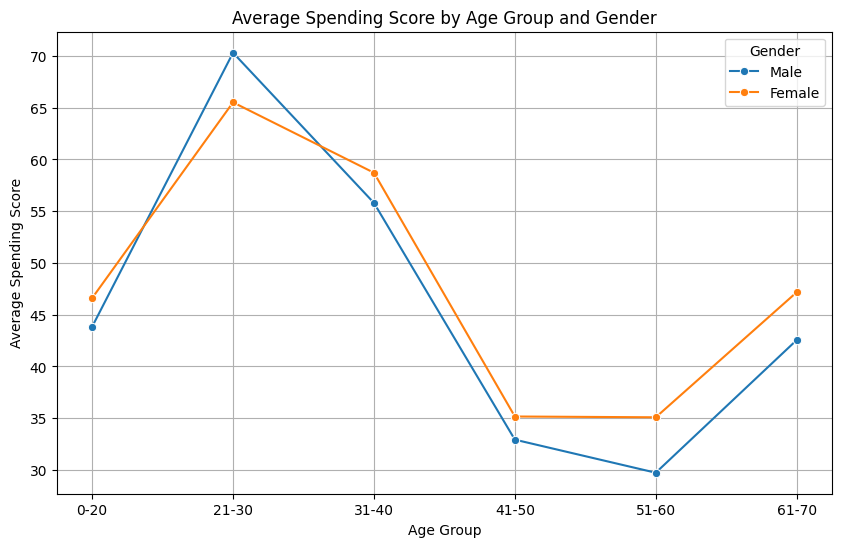

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/HP/Downloads/archive (1)/Mall_Customers.csv")
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 20, 30, 40, 50, 60, 70],
                        labels=['0-20', '21-30', '31-40', '41-50', '51-60', '61-70'])
spending_by_age_gender = df.groupby(['AgeGroup', 'Gender'])['Spending Score (1-100)'].mean().reset_index()
spending_by_age_gender['Gender'] = spending_by_age_gender['Gender'].map({0: 'Male', 1: 'Female'})
spending_by_age_gender['AgeGroup'] = spending_by_age_gender['AgeGroup'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(data=spending_by_age_gender, x='AgeGroup', y='Spending Score (1-100)', hue='Gender', marker='o')
plt.title("Average Spending Score by Age Group and Gender")
plt.ylabel("Average Spending Score")
plt.xlabel("Age Group")
plt.grid(True)
plt.show()